# 03. CRM Analytics - Product Analytics

**Input data:** cleaned datasets from `data/processed/` (output of notebook 02)
**Goal:** identify the business growth lever, build a metrics tree and formulate a hypothesis that can be tested in 2 weeks

`Product analytics assignment`  
Identify the business growth lever and formulate a hypothesis for improving the business
process to grow key metrics, describing the test mechanics — the test itself must not
take longer than 2 weeks.  
1. Calculate unit economics per product.  
2. Use unit economics to identify business growth points.  
3. Understand the business metrics tree.  
4. Determine which product metric each growth point affects and formulate hypotheses.  
5. Describe the hypothesis-testing method, including the success condition.

## Executive summary

**Question:** where is the growth lever of the business, and how can it be tested within two weeks?

**Answer:** the conversion of potential clients into paying students (C1 = 4.70%).

| Metric | Baseline (Jul 2023 - May 2024) |
| :--- | ---: |
| Potential clients (UA) / paying students (B) | 17,250 / 810 |
| C1 = B / UA | 4.70% |
| Marketing budget (AC) | EUR 138,152.50 |
| Revenue (Rev) | EUR 3,347,317.73 |
| CPA = AC / UA / CAC = AC / B | EUR 8.01 / EUR 170.56 |
| AOV (per paid month) / APC (paid months per student) | EUR 737.29 / 5.60 |
| CLTV = AOV x APC / LTV = CLTV x C1 | EUR 4,132.49 / EUR 194.05 |
| CM = UA x (LTV - CPA) = Rev - AC | EUR 3,209,165 |
| CLTV / CAC (equals LTV / CPA) | 24.2 |

**Why C1**
1. Marketing is only 4.1% of revenue. Cutting CPA by 10% is worth about EUR 14K of CM; raising C1 by 10% is worth about EUR 335K.
2. C1 differs five-fold between channels (from 1.8% for the CRM base to 9.7% for Organic), so there is room to grow without extra ad spend.
3. C1 reacts in weeks. APC depends on course length (months), and AOV depends on pricing.

**Hypothesis:** contacting a new lead within 30 minutes (instead of the current median of 5.5 hours) increases the share of qualified leads. A/B test at lead level, 14 days of exposure, about 380 leads per arm. Payments are confirmed on the same cohorts at day 45-60, because the median time to payment is 17.5 days.

**Impact:** each +1% (relative) of C1 adds about EUR 33.5K to CM at constant spend; +15% adds about EUR 0.5M (upper bound, see limitations).

**Limitations:** COGS is not available in the data and is set to 0, so CLTV, LTV and CM are revenue-based; months of study are counted up to 31 May 2024 (recent cohorts have studied less so far), so CLTV is a lower bound. SLA effects are observational until the test is run. Marketing spend is not tagged by product, so product-level CAC rests on an allocation assumption (Section 1.2).

# 1. Imports & Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

sys.path.append('../src')   # helpers.py lives in src/
import helpers as h

In [2]:
# Visualization settings
sns.set_style('whitegrid')
sns.set_palette('deep')

# Pandas settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Paths (notebook lives in notebooks/, data lives in data/)
PROJECT_ROOT = Path().resolve().parent
# RAW          = PROJECT_ROOT / 'data' / 'raw'
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
# BACKUP       = PROJECT_ROOT / 'data' / 'processed' / 'backup'
# IMAGES       = PROJECT_ROOT / 'images'
REPORTS       = PROJECT_ROOT / 'report'

In [3]:
# Delimiter strings for formatted output:

string_delimiter = f"{'-':-^99}"
print(string_delimiter)
string_delimiter1 = f"{'=':=^99}"
print(string_delimiter1)

---------------------------------------------------------------------------------------------------


---
# 2. Loading Data

In [4]:
# Dictionary of cleaned datasets to load:
datasets = {'deals': 'deals_final_ue.pkl', 
            # 'contacts': 'contacts_cleaned.pkl',
            # 'calls': 'calls_cleaned.pkl',
            'spend': 'spend_cleaned.pkl'
            }

In [5]:
# Load each dataset by filename:
loaded_data = {}

for name, filename in datasets.items():
    filepath = PROCESSED / filename  
  
    # Determine format from the file extension
    if filepath.suffix == '.pkl':
        df = pd.read_pickle(filepath)
    else:
        raise ValueError(f"Unsupported file format: {filepath.suffix}")
    
    loaded_data[name] = df # for accessing the loaded data
    
    print(f"Loaded: {filename}")
    print(f"{name}: {df.shape}\n")

Loaded: deals_final_ue.pkl
deals: (18250, 31)

Loaded: spend_cleaned.pkl
spend: (19862, 8)



In [6]:
# Access the loaded datasets
deals = loaded_data['deals']
spend = loaded_data['spend']

## 1. Full Technical Audit of All Date/Time Fields

In [7]:
# Technical audit of all date/time fields
def get_date_bounds(df, columns):
    res = {}
    for col in columns:
        if col in df.columns:
            temp_dt = pd.to_datetime(df[col], errors='coerce')
            res[col] = (temp_dt.min(), temp_dt.max())
    return res

audit_data = {
    # 'CONTACTS': get_date_bounds(contacts, ['created_time', 'created_date', 'modified_time']),
    # 'CALLS':    get_date_bounds(calls, ['call_start_time', 'call_start_date']),
    'DEALS':    get_date_bounds(deals, ['created_time', 'created_date']),
    'SPEND':    get_date_bounds(spend, ['spend_date'])
}

print(f"{'Dataset':<12} | {'Field':<18} | {'Start':<12} | {'End':<12}")
print(string_delimiter1)

for ds_name, cols in audit_data.items():
    for col_name, (d_min, d_max) in cols.items():
        print(f"{ds_name:<12} | {col_name:<18} | {str(d_min.date()):<12} | {str(d_max.date()):<12}")
        print(string_delimiter)
# Fixed reporting period:

SYNC_START = pd.Timestamp('2023-07-01')
SYNC_END   = pd.Timestamp('2024-05-31')

print(f"FIXED PERIOD:")
print(f"Selected period: {SYNC_START.date()} — {SYNC_END.date()}")

Dataset      | Field              | Start        | End         
DEALS        | created_time       | 2023-07-03   | 2024-05-31  
---------------------------------------------------------------------------------------------------
DEALS        | created_date       | 2023-07-03   | 2024-05-31  
---------------------------------------------------------------------------------------------------
SPEND        | spend_date         | 2023-07-03   | 2024-06-21  
---------------------------------------------------------------------------------------------------
FIXED PERIOD:
Selected period: 2023-07-01 — 2024-05-31


## 2. Data Preprocessing

In [8]:
# Print column names and dtypes for the datasets in use (DEALS & SPEND)
for name, df in {
    'deals': deals,
    # 'calls': calls,
    # 'contacts': contacts,
    'spend': spend
}.items():
    print(f"\n{'='*15} {name.upper()} {'='*15}")
    print(df.dtypes)


=============== DEALS ===============
deals_id                string[python]
deal_owner_name                 object
closing_date            datetime64[ns]
quality                       category
stage                         category
lost_reason                   category
page                          category
campaign                        object
sla                    timedelta64[ns]
ad                              object
ad_group                        object
source                          object
payment_type                  category
product                       category
education_type                category
created_time            datetime64[ns]
course_duration                  Int64
months_of_study                  Int64
initial_amount_paid            float64
offer_total_amount             float64
contact_id              string[python]
city                            object
created_date            datetime64[ns]
is_paid                           bool
level_of_deutsch         

In [9]:
# --- UNIT-ECONOMICS FUNCTION (definitions follow the glossary below) ---
def calc_unit_economics(df: pd.DataFrame, ua_total: float, ac_total: float) -> dict:
    """
    Unit economics from CRM data.
    ua_total: unique potential clients (contacts), ac_total: marketing budget (sum of spend).
    COGS is not available in the data, so COGS = 0 and CLTV / LTV / CM are revenue-based.
    """
    ue = {"UA": ua_total, "AC": ac_total}

    paid = df[df['is_successful_closed'] == True]            # Payment Done and months_of_study > 0 = is_real_student

    ue["B"]    = paid['student_id'].nunique()                 # unique paying students
    ue["T"]    = paid['months_of_study'].sum()                # transactions = paid months
    ue["REV"]  = paid['Ri'].sum()

    ue["C1"]   = ue["B"] / ue["UA"] * 100 if ue["UA"] else 0
    ue["CPA"]  = ue["AC"] / ue["UA"] if ue["UA"] else 0       # cost per potential client
    ue["CAC"]  = ue["AC"] / ue["B"] if ue["B"] else 0         # cost per paying student
    ue["AOV"]  = ue["REV"] / ue["T"] if ue["T"] else 0        # revenue per paid month
    ue["APC"]  = ue["T"] / ue["B"] if ue["B"] else 0          # paid months per student
    ue["CLTV"] = ue["AOV"] * ue["APC"]                        # = REV / B
    ue["LTV"]  = ue["CLTV"] * ue["C1"] / 100                  # value of one potential client
    ue["CM"]   = ue["UA"] * (ue["LTV"] - ue["CPA"])           # = REV - AC when COGS = 0
    return ue

In [10]:
# First rows
h.descr_df(deals)

,Column name,Dtype,Value count,Missing (NaN),Unique values,Min,Q1,Mean,Q2 Median,Q3,Max,Range,IQR
0,sla,timedelta64[ns],14077,4173,12237,0 days 00:00:03,0 days 01:12:27,1 days 08:13:28.836399801,0 days 05:31:09,0 days 15:37:35,311 days 10:34:24,311 days 10:34:21,0 days 14:25:08
1,course_duration,Int64,3344,14906,2,6,11,10.24,11.00,11,11,5,0
2,months_of_study,Int64,814,17436,11,1,3,5.58,6.00,8,11,10,5
3,initial_amount_paid,float64,3066,15184,20,100.00,1000.00,1180.01,1000.00,1000.00,11500.00,11400.00,0.00
4,offer_total_amount,float64,3113,15137,18,1000.00,5000.00,8947.71,11000.00,11000.00,11500.00,10500.00,6000.00
5,deal_duration_days,float64,12554,5696,233,0.00,1.00,16.70,4.00,14.00,335.00,335.00,13.00
6,Ri,float64,18250,0,136,0.00,0.00,183.41,0.00,0.00,11500.00,11500.00,0.00
7,SLA_hours,float64,14077,4173,12237,0.00,1.21,32.22,5.52,15.63,7474.57,7474.57,14.42


In [11]:
# 1. SAFE NaN filtering BEFORE applying the logic
deals['m_of_study'] = pd.to_numeric(deals['months_of_study'], errors='coerce').fillna(0)

deals['is_successful_closed'] = (
    (deals['stage'] == 'Payment Done') & 
    (deals['m_of_study'] > 0)
).fillna(False).astype(bool)

# unique student key: contact_id; a paid deal without contact_id counts as a separate student (key = deal id)
deals['student_id'] = deals['contact_id'].fillna('deal_' + deals['deals_id'].astype(str))

# 2. AOVi without dividing by NaN
deals['AOVi'] = np.where(
    deals['m_of_study'] > 0,
    deals['Ri'] / deals['m_of_study'],
    0
)

# 3. Apply the product filter
products = ['Digital Marketing', 'UX/UI Design', 'Web Developer']
deals['product'] = deals['product'].astype(str).str.strip()

deals_small = deals[
    deals['product'].isin(products)
][['created_date', 'stage', 'product', 'course_duration', 'm_of_study', 
   'initial_amount_paid', 'offer_total_amount', 'Ri', 'AOVi', 'is_successful_closed']
].copy()

print(f"deals_small: {deals_small.shape}")
deals_small.sample(5)

deals_small: (3344, 10)


,created_date,stage,product,course_duration,m_of_study,initial_amount_paid,offer_total_amount,Ri,AOVi,is_successful_closed
8806,2024-03-04,Payment Done,UX/UI Design,11,4,300.00,4000.00,1410.00,352.50,True
2076,2024-05-26,Payment Done,UX/UI Design,11,2,1000.00,11000.00,2000.00,1000.00,True
10345,2024-02-09,Payment Done,Web Developer,6,2,1000.00,5000.00,1800.00,900.00,True
2767,2024-05-12,Lost,UX/UI Design,11,0,1000.00,11000.00,0.00,0.00,False
8460,2024-03-09,Lost,Digital Marketing,11,0,NaN,NaN,0.00,0.00,False


---
*Identify the business growth lever and formulate a hypothesis for improving the growth process, describing the test mechanics — the test must not take longer than 2 weeks.*  

# Section 1. Unit Economics by Product

Unit economics per product: calculated separately for Digital Marketing, UX/UI Design, and Web Developer.

## Metric Glossary

| Metric | Definition | Value |
| :--- | :--- | ---: |
| **UA** | Unique potential clients (`contact_id` in contacts) | 17,250 |
| **AC** | Marketing budget = sum of `spend` | EUR 138,152.50 |
| **B** | Unique paying students: stage = Payment Done and months_of_study > 0 | 810 |
| **T** | Transactions = total paid months of study | 4,540 |
| **Rev** | Revenue = sum of `Ri` | EUR 3,347,317.73 |
| **C1** | B / UA | 4.70% |
| **CPA** | AC / UA, cost per potential client | EUR 8.01 |
| **CAC** | AC / B, cost per paying student | EUR 170.56 |
| **AOV** | Rev / T, revenue per paid month | EUR 737.29 |
| **APC** | T / B, paid months per student | 5.60 |
| **CLTV** | AOV x APC = Rev / B (COGS = 0) | EUR 4,132.49 |
| **LTV** | CLTV x C1, value of one potential client | EUR 194.05 |
| **CM** | UA x (LTV - CPA) = Rev - AC (COGS = 0) | EUR 3,209,165 |

Branches of the model: costs `UA -> CPA -> AC`; revenue `C1 -> AOV -> APC -> CLTV -> LTV`; top of the tree `CM`.
Ratios must use the same unit: **CLTV / CAC** (per student) or **LTV / CPA** (per potential client). Comparing LTV with CAC mixes a per-lead value with a per-student cost.

* **T counts months studied up to the data cutoff (31 May 2024).** The average months of study falls from 9.7 (August 2023 leads) to 1.9 (May 2024 leads) at a course length of about 10-11 months, so Rev, T, APC and CLTV of recent cohorts are still accumulating and CLTV is a lower bound of lifetime revenue.

## 1.1. Overall Unit Economics Calculation (Baseline)

In [12]:
# 1.1. Overall unit economics calculation (Baseline)

# Fixed constants
TOTAL_UA = 17250
TOTAL_AC = 138152.50

# Use the current success flag (is_successful_closed / is_real_student)
# Here we rely on the filter created above
paid_total = deals[deals['is_successful_closed'] == True]

ue_total = {}
ue_total["UA"] = TOTAL_UA
ue_total["AC"] = TOTAL_AC
ue_total["B"] = paid_total['student_id'].nunique()  # Unique buyers (customers)

# T defined as the sum of months of study
ue_total["T"] = paid_total['m_of_study'].sum()      

ue_total["REV"] = paid_total['Ri'].sum()           # Total revenue

# --- Derived metrics ---

# Potential client to paying student conversion (%)
ue_total["C1"] = (ue_total["B"] / ue_total["UA"] * 100)

# Cost of acquiring one potential client
ue_total["CPA"] = ue_total["AC"] / ue_total["UA"]

# Average price per month of study (T is now in months)
ue_total["AOV"] = ue_total["REV"] / ue_total["T"] if ue_total["T"] > 0 else 0

# Average number of paid months per student
ue_total["APC"] = ue_total["T"] / ue_total["B"] if ue_total["B"] > 0 else 0

# Value of one student over their full lifetime
ue_total["CLTV"] = ue_total["AOV"] * ue_total["APC"]

# Value of one potential client (LTV)
ue_total["LTV"] = ue_total["CLTV"] * ue_total["C1"] / 100

# Cost of acquiring one paying student
ue_total["CAC"] = ue_total["AC"] / ue_total["B"] if ue_total["B"] > 0 else 0

# Final contribution margin
ue_total["CM"] = ue_total["UA"] * (ue_total["LTV"] - ue_total["CPA"])

# Build the summary table
total_report = pd.DataFrame([ue_total]).round(2)
display(total_report)

# Consistency checks
assert abs(ue_total['CM'] - (ue_total['REV'] - ue_total['AC'])) < 1, 'CM must equal REV - AC when COGS = 0'
assert abs(ue_total['CLTV'] - ue_total['REV'] / ue_total['B']) < 0.01
print(f"CLTV / CAC = {ue_total['CLTV'] / ue_total['CAC']:.1f}   |   LTV / CPA = {ue_total['LTV'] / ue_total['CPA']:.1f}   |   ROMI = {(ue_total['REV'] - ue_total['AC']) / ue_total['AC'] * 100:,.0f}%")

,UA,AC,B,T,REV,C1,CPA,AOV,APC,CLTV,LTV,CAC,CM
0,17250,138152.50,810,4540,3347317.73,4.70,8.01,737.29,5.60,4132.49,194.05,170.56,3209165.23


CLTV / CAC = 24.2   |   LTV / CPA = 24.2   |   ROMI = 2,323%


**Is the business profitable? Yes, by a wide margin.**
* **CLTV / CAC = EUR 4,132 / EUR 171 = 24.2** (the same ratio as LTV / CPA = EUR 194 / EUR 8.01). COGS is not available, so this is an upper bound; even a large cost of delivery leaves a wide safety margin.
* **Scale:** 17,250 potential clients become 810 paying students and EUR 3.35M of revenue on EUR 138K of spend (ROMI about 2,320%). Marketing is 4.1% of revenue.
* **Payback:** CAC (EUR 171) is covered by the first payment (median initial payment EUR 1,000).

**Risks and checks**
* A student has paid for 5.60 months on average so far (courses last 10-11 months), so value comes from duration: CLTV is 5.6 times AOV. Early drop-out is the main threat to this value.
* AOV is a revenue-per-paid-month figure (EUR 737), not a price of a single purchase.
* C1 = 4.70%: 95 of 100 potential clients never pay. This is where the largest absolute gain is possible.

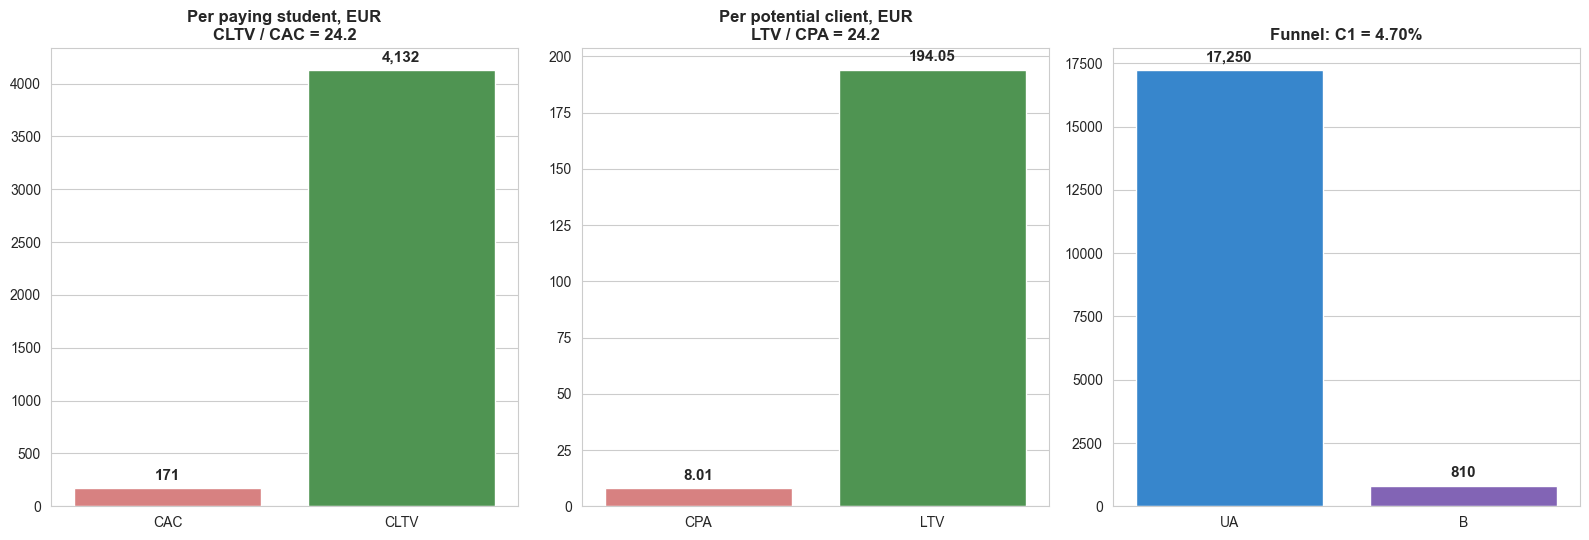

CLTV / CAC: 24.2
LTV / CPA:  24.2
Marketing share of revenue (AC / Rev): 4.1%
ROMI: 2,323%


In [13]:
# Baseline picture, built from ue_total (no hard-coded numbers)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5.5))

def bar_labels(ax, fmt='{:,.0f}'):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 4), textcoords='offset points')

# 1. Per paying student: what we pay vs what we earn
sns.barplot(x=['CAC', 'CLTV'], y=[ue_total['CAC'], ue_total['CLTV']], hue=['CAC', 'CLTV'], palette=['#E57373', '#43A047'], legend=False, ax=ax1)
ax1.set_title(f"Per paying student, EUR\nCLTV / CAC = {ue_total['CLTV'] / ue_total['CAC']:.1f}", fontweight='bold')
bar_labels(ax1)

# 2. Per potential client: same ratio on the lead level
sns.barplot(x=['CPA', 'LTV'], y=[ue_total['CPA'], ue_total['LTV']], hue=['CPA', 'LTV'], palette=['#E57373', '#43A047'], legend=False, ax=ax2)
ax2.set_title(f"Per potential client, EUR\nLTV / CPA = {ue_total['LTV'] / ue_total['CPA']:.1f}", fontweight='bold')
bar_labels(ax2, '{:,.2f}')

# 3. Funnel: potential clients -> paying students
sns.barplot(x=['UA', 'B'], y=[ue_total['UA'], ue_total['B']], hue=['UA', 'B'], palette=['#1E88E5', '#7E57C2'], legend=False, ax=ax3)
ax3.set_title(f"Funnel: C1 = {ue_total['C1']:.2f}%", fontweight='bold')
bar_labels(ax3)

plt.tight_layout()
plt.show()

print(f"CLTV / CAC: {ue_total['CLTV'] / ue_total['CAC']:.1f}")
print(f"LTV / CPA:  {ue_total['LTV'] / ue_total['CPA']:.1f}")
print(f"Marketing share of revenue (AC / Rev): {ue_total['AC'] / ue_total['REV'] * 100:.1f}%")
print(f"ROMI: {(ue_total['REV'] - ue_total['AC']) / ue_total['AC'] * 100:,.0f}%")

**Healthy unit economics**
* CPA of EUR 8 per potential client and CAC of EUR 171 per student are low compared with EUR 4,132 of revenue per student (CLTV / CAC = 24).
* Marketing takes 4.1% of revenue, so saving on traffic cannot move CM much: the biggest lever is what happens to the clients already acquired.
* COGS is not available (set to 0), so margins are upper bounds.

**Focus areas**
1. **Raise C1** (95% of potential clients do not pay). Fast feedback, no extra ad spend.
2. Keep students longer (APC 5.60 against courses of up to 11 months). High value, but results appear only after months.
3. Keep CPA low while scaling UA.

## 1.2. Unit Economics by Product

Marketing spend and potential clients are not tagged by product, so UA and AC are allocated to products in proportion to their share of leads that reached a product (an assumption). Revenue, students, AOV, APC and CLTV need no allocation. The totals reconcile to the portfolio: the sum of product CM equals Rev - AC.

In [14]:
# 1.2 Unit economics by product (UA and AC allocated by lead share)
TOTAL_UA = ue_total['UA']
TOTAL_AC = ue_total['AC']

target_products = ['Digital Marketing', 'UX/UI Design', 'Web Developer']

# Allocation key: leads whose product is known (CRM deals)
lead_counts = deals[deals['product'].isin(target_products)].groupby('product').size().reindex(target_products)
lead_share = lead_counts / lead_counts.sum()
print(f"Leads with a known product: {lead_counts.sum():,} of {len(deals):,} ({lead_counts.sum() / len(deals) * 100:.1f}%)")

paid_total = deals[deals['is_successful_closed'] == True]
ue_results = []

for prod in target_products:
    paid = paid_total[paid_total['product'] == prod]

    ue = {"product": prod}
    ue["UA"]  = TOTAL_UA * lead_share[prod]          # allocated potential clients
    ue["AC"]  = TOTAL_AC * lead_share[prod]          # allocated marketing budget
    ue["B"]   = paid['student_id'].nunique()         # unique paying students
    ue["T"]   = paid['m_of_study'].sum()             # paid months
    ue["REV"] = paid['Ri'].sum()

    ue["CPA"]  = ue["AC"] / ue["UA"]
    ue["C1"]   = ue["B"] / ue["UA"] * 100
    ue["AOV"]  = ue["REV"] / ue["T"] if ue["T"] > 0 else 0
    ue["APC"]  = ue["T"] / ue["B"] if ue["B"] > 0 else 0
    ue["CLTV"] = ue["AOV"] * ue["APC"]
    ue["LTV"]  = ue["CLTV"] * ue["C1"] / 100
    ue["CAC"]  = ue["AC"] / ue["B"] if ue["B"] > 0 else 0
    ue["CM"]   = ue["UA"] * (ue["LTV"] - ue["CPA"])
    ue["CLTV/CAC"] = ue["CLTV"] / ue["CAC"] if ue["CAC"] > 0 else 0
    ue_results.append(ue)

final_ue_df = pd.DataFrame(ue_results).set_index('product')

# Total row from the portfolio calculation (unique students are not additive across products)
total_row = dict(ue_total)
total_row["CLTV/CAC"] = ue_total["CLTV"] / ue_total["CAC"]
final_ue_df.loc['TOTAL (portfolio)'] = pd.Series(total_row)

display(final_ue_df.round(2))

# Reconciliation
products_only = final_ue_df.loc[target_products]
print(f"Sum of product revenue: {products_only['REV'].sum():,.2f}  |  portfolio: {ue_total['REV']:,.2f}")
print(f"Sum of product CM:      {products_only['CM'].sum():,.2f}  |  portfolio CM: {ue_total['CM']:,.2f}")
print(f"Sum of product students: {products_only['B'].sum():.0f}  |  unique students overall: {ue_total['B']} (a client who bought two products is counted in both)")

Leads with a known product: 3,344 of 18,250 (18.3%)


,UA,AC,B,T,REV,CPA,C1,AOV,APC,CLTV,LTV,CAC,CM,CLTV/CAC
product,,,,,,,,,,,,,,
Digital Marketing,9667.02,77421.59,463.00,2886.00,2140210.91,8.01,4.79,741.58,6.23,4622.49,221.39,167.22,2062789.32,27.64
UX/UI Design,4946.99,39619.69,219.00,1155.00,863426.82,8.01,4.43,747.56,5.27,3942.59,174.54,180.91,823807.13,21.79
Web Developer,2635.99,21111.22,130.00,499.00,343680.00,8.01,4.93,688.74,3.84,2643.69,130.38,162.39,322568.78,16.28
TOTAL (portfolio),17250.00,138152.50,810.00,4540.00,3347317.73,8.01,4.70,737.29,5.60,4132.49,194.05,170.56,3209165.23,24.23


Sum of product revenue: 3,347,317.73  |  portfolio: 3,347,317.73
Sum of product CM:      3,209,165.23  |  portfolio CM: 3,209,165.23
Sum of product students: 812  |  unique students overall: 810 (a client who bought two products is counted in both)


In [15]:
# 1.3 Scenario: what is a relative C1 increase worth?
# Assumptions: spend (UA, AC) constant, CLTV per student unchanged, COGS = 0 -> this is an upper bound.
k = 0.15          # +15% relative change of C1 (4.70% -> 5.40%)

sim_df = final_ue_df.copy()
sim_df['C1_forecast']  = sim_df['C1'] * (1 + k)
sim_df['B_forecast']   = sim_df['UA'] * sim_df['C1_forecast'] / 100
sim_df['LTV_forecast'] = sim_df['CLTV'] * sim_df['C1_forecast'] / 100
sim_df['CM_forecast']  = sim_df['UA'] * (sim_df['LTV_forecast'] - sim_df['CPA'])
sim_df['Profit_Gain_EUR'] = sim_df['CM_forecast'] - sim_df['CM']

report = sim_df[['C1', 'C1_forecast', 'B', 'B_forecast', 'CM', 'CM_forecast', 'Profit_Gain_EUR']].copy()
report.columns = ['C1 (base), %', f'C1 (+{k*100:.0f}%), %', 'Students (base)', 'Students (forecast)',
                  'CM (base), EUR', 'CM (forecast), EUR', 'CM gain, EUR']

print(f"SCENARIO: C1 +{k*100:.0f}% (relative) at constant spend")
display(report.round(2))

# Sensitivity of the portfolio to the size of the C1 uplift
sens = pd.DataFrame({'C1 uplift, %': [5, 10, 15, 20, 25]})
sens['New C1, %']     = ue_total['C1'] * (1 + sens['C1 uplift, %'] / 100)
sens['Extra students'] = ue_total['B'] * sens['C1 uplift, %'] / 100
sens['Extra revenue = CM gain, EUR'] = ue_total['REV'] * sens['C1 uplift, %'] / 100
display(sens.round(2))
print(f"Rule of thumb: +1% relative C1 = +EUR {ue_total['REV'] * 0.01:,.0f} of CM at constant spend.")

SCENARIO: C1 +15% (relative) at constant spend


,"C1 (base), %","C1 (+15%), %",Students (base),Students (forecast),"CM (base), EUR","CM (forecast), EUR","CM gain, EUR"
product,,,,,,,
Digital Marketing,4.79,5.51,463.00,532.45,2062789.32,2383820.96,321031.64
UX/UI Design,4.43,5.09,219.00,251.85,823807.13,953321.15,129514.02
Web Developer,4.93,5.67,130.00,149.50,322568.78,374120.78,51552.00
TOTAL (portfolio),4.70,5.40,810.00,931.50,3209165.23,3711262.89,502097.66


,"C1 uplift, %","New C1, %",Extra students,"Extra revenue = CM gain, EUR"
0,5,4.93,40.50,167365.89
1,10,5.17,81.00,334731.77
2,15,5.40,121.50,502097.66
3,20,5.63,162.00,669463.55
4,25,5.87,202.50,836829.43


Rule of thumb: +1% relative C1 = +EUR 33,473 of CM at constant spend.


---
# Section 2. Business Metrics Tree

The tree decomposes the key figure (CM) into the metrics that the business can influence. It is the map used in Section 3 to choose the growth lever.

## Metrics Tree and Decomposition

This metrics tree shows how business performance decomposes from a top-level goal (Contribution Margin) down to atomic data: user acquisition, funnel conversion, order economics and marketing spend.

Color coding: **purple** goal (key figure), **blue** financial, **green** decision (levers), **red** product, **yellow** atomic, **gray** info.


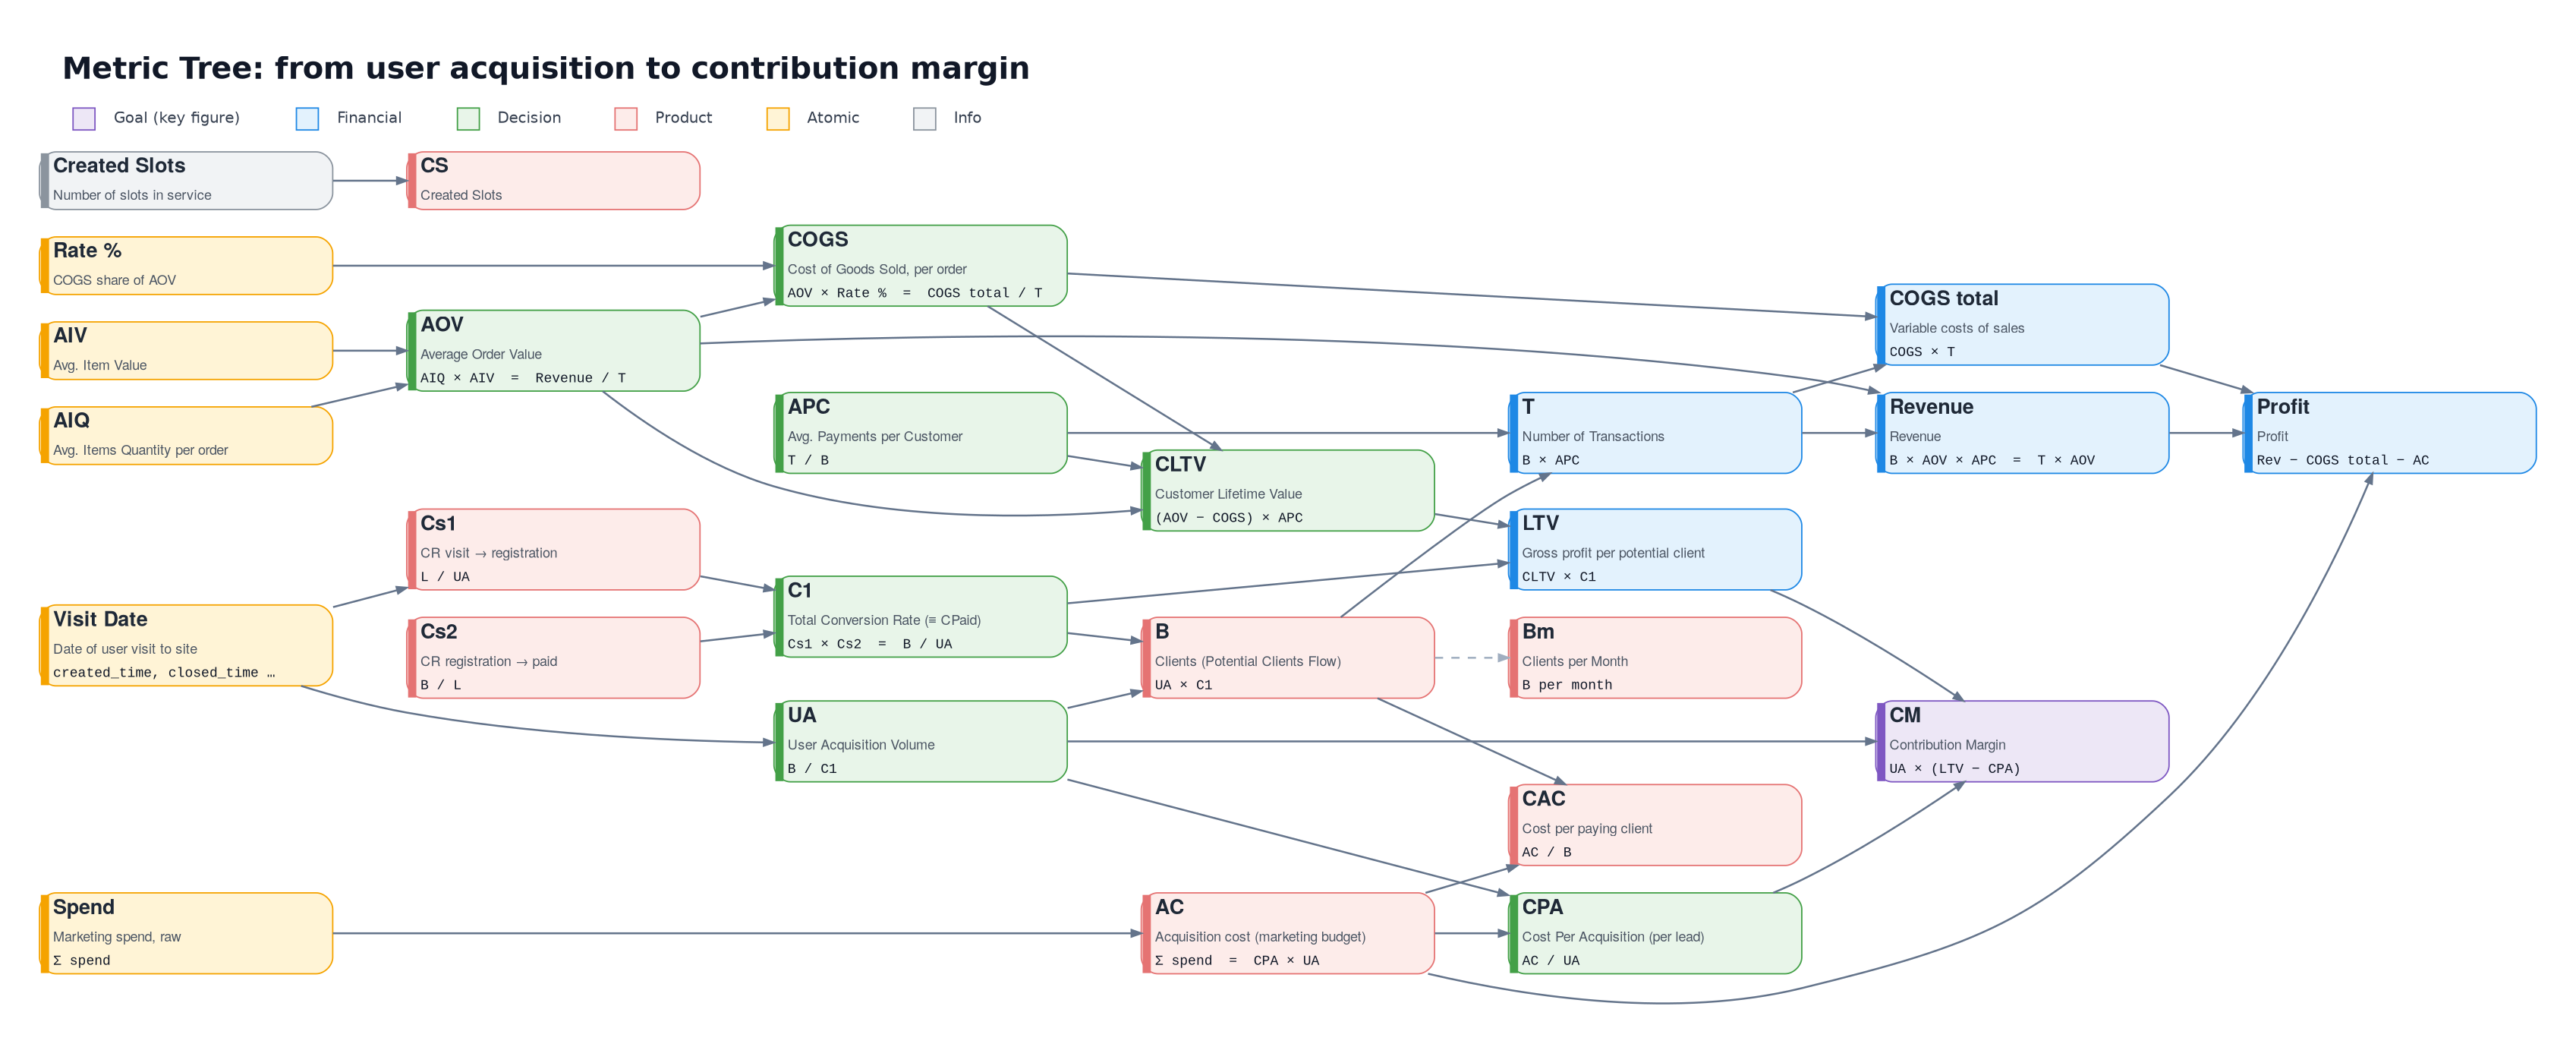

### Key Goal and Financial Metrics

* **Contribution Margin (CM):** $\text{UA} \times (\text{LTV} - \text{CPA})$, equivalent to $\text{UA} \times (\text{CLTV} \times \text{C1} - \text{CPA})$
* **Revenue (Rev):** $B \times \text{AOV} \times \text{APC}$, equivalent to $T \times \text{AOV}$
* **Profit:** $\text{Rev} - \text{COGS total} - \text{AC}$

---

### Metric Breakdown

#### Goal and Financial

| Metric | Description | Formula |
| :--- | :--- | :--- |
| **CM** | Contribution Margin, the key business indicator | $\text{UA} \times (\text{LTV} - \text{CPA})$ |
| **Revenue** | Total revenue | $B \times \text{AOV} \times \text{APC} = T \times \text{AOV}$ |
| **Profit** | Profit after variable costs and acquisition spend | $\text{Rev} - \text{COGS total} - \text{AC}$ |
| **T** | Number of transactions | $B \times \text{APC}$ |
| **LTV** | Gross profit per potential client | $\text{CLTV} \times \text{C1}$ |
| **COGS total** | Variable costs directly tied to sales | $\text{COGS} \times T$ |

#### Decision (levers)

| Metric | Description | Formula |
| :--- | :--- | :--- |
| **UA** | User Acquisition Volume: number of unique potential clients | $B / \text{C1}$ |
| **C1** | Total Conversion Rate: potential client to paying client (equals CPaid) | $\text{Cs1} \times \text{Cs2} = B / \text{UA}$ |
| **CPA** | Cost Per Acquisition of one potential client | $\text{AC} / \text{UA}$ |
| **AOV** | Average Order Value | $\text{AIQ} \times \text{AIV} = \text{Rev} / T$ |
| **COGS** | Cost of Goods Sold per order (variable costs) | $\text{AOV} \times \text{Rate}\% = \text{COGS total} / T$ |
| **APC** | Average Payment Count: transactions per customer | $T / B$ |
| **CLTV** | Customer Lifetime Value: gross profit per paying client | $(\text{AOV} - \text{COGS}) \times \text{APC}$ |

#### Product

| Metric | Description | Formula |
| :--- | :--- | :--- |
| **B** | Clients: flow of paying clients | $\text{UA} \times \text{C1}$ |
| **Bm** | Clients per month | $B$ per month |
| **AC** | Acquisition cost: total marketing budget | $\sum \text{spend} = \text{CPA} \times \text{UA}$ |
| **CAC** | Cost of acquiring one paying client | $\text{AC} / B$ |
| **Cs1** | Conversion: visit to registration | $L / \text{UA}$ |
| **Cs2** | Conversion: registration to paid | $B / L$ |
| **CS** | Created Slots: slots generated in the service | count of slots |

Here $L$ is the number of registered users.

---

### Atomic and Info Data

| Item | Type | Description |
| :--- | :--- | :--- |
| **Visit Date** | Atomic | Timestamps of the user lifecycle (`created_time`, `modified_time`, `closed_time`) |
| **Spend** | Atomic | Raw marketing spend; aggregated into AC |
| **AIQ** | Atomic | Average items quantity per order; drives AOV |
| **AIV** | Atomic | Average item value; drives AOV |
| **Rate %** | Atomic | COGS share of AOV |
| **Created Slots** | Info | Number of slots created in the service |

---

### Modeling Notes

* UA, C1 and B are linked by $B = \text{UA} \times \text{C1}$. In planning, UA and C1 are the inputs and B is derived; in analysis of actuals, B and UA are observed and C1 is derived.
* AOV and COGS have two equivalent definitions: a planning one (from AIQ, AIV and Rate %) and a factual one (from Revenue, COGS total and T). The factual form is used to validate the model.
* AC is a fact when taken as the sum of spend, and a plan when taken as $\text{CPA} \times \text{UA}$.

---

### Notes for this dataset

* **COGS is not available in the data and is set to 0.** The tree keeps the COGS branch for completeness; with COGS = 0 the model reduces to CLTV = AOV x APC, LTV = CLTV x C1, CM = Rev - AC and Profit = CM.
* In the channel and manager tables of notebook 02 the funnel starts at **Leads** (CRM deals) because campaign, source and manager are stored on the deal. Portfolio-level metrics use UA = 17,250 unique potential clients.
* Nodes shown in the tree but not computed here: Cs1, Cs2, L, Bm, CS, AIQ, AIV, Rate %. They define the next level of detail and are not needed for the conclusions below.

---
# Section 3. Growth Points

*Finding the bottleneck (Theory of Constraints).* A lever is a good growth point when (1) a realistic change moves CM noticeably, (2) there is evidence of headroom, and (3) the result is visible fast enough to test within two weeks.

## 3.1. Which lever moves CM the most?

The table changes one lever at a time by 10% and recalculates CM with the model `CM = UA x (C1 x AOV x APC - CPA)`.

In [16]:
def cm_model(UA, C1, AOV, APC, CPA):
    """CM = UA x (LTV - CPA), LTV = C1 x AOV x APC (COGS = 0). C1 in %."""
    return UA * (C1 / 100 * AOV * APC - CPA)

base = dict(UA=ue_total['UA'], C1=ue_total['C1'], AOV=ue_total['AOV'], APC=ue_total['APC'], CPA=ue_total['CPA'])
cm_base = cm_model(**base)
assert abs(cm_base - ue_total['CM']) < 1, "model must reproduce the baseline CM"

levers = [
    ('C1',  +0.10, 'days to weeks'),
    ('AOV', +0.10, 'weeks to months (pricing / offer change)'),
    ('APC', +0.10, 'months (students stay longer)'),
    ('UA',  +0.10, 'weeks (needs +10% spend at constant CPA)'),
    ('CPA', -0.10, 'weeks'),
]
rows = []
for name, change, speed in levers:
    p = dict(base)
    p[name] = p[name] * (1 + change)
    d_cm = cm_model(**p) - cm_base
    rows.append({'Lever': name, 'Change': f'{change:+.0%}', 'CM gain, EUR': d_cm,
                 'CM gain, %': d_cm / cm_base * 100, 'Time to see the effect': speed})

lever_table = pd.DataFrame(rows).sort_values('CM gain, EUR', ascending=False)
display(lever_table.round(1))

,Lever,Change,"CM gain, EUR","CM gain, %",Time to see the effect
1,AOV,+10%,334731.80,10.40,weeks to months (pricing / offer change)
2,APC,+10%,334731.80,10.40,months (students stay longer)
0,C1,+10%,334731.80,10.40,days to weeks
3,UA,+10%,320916.50,10.00,weeks (needs +10% spend at constant CPA)
4,CPA,-10%,13815.20,0.40,weeks


**Reading the table**
* C1, AOV and APC are multiplicative, so +10% on any of them adds the same EUR 335K (+10% of revenue). CPA is different: marketing is only 4.1% of revenue, so a 10% cheaper acquisition is worth EUR 14K.
* The choice between C1, AOV and APC is therefore made on headroom and speed of feedback, not on size of effect.

## 3.2. Where is the headroom? C1 and lead quality by source

In [17]:
n_weeks = ((SYNC_END - SYNC_START).days + 1) / 7
quality_ok = ['A - High', 'B - Medium', 'C - Low']

paid_total = deals[deals['is_successful_closed'] == True]

channels = deals.groupby('source', observed=True).agg(
    Leads=('contact_id', 'size'),
    Qualified_rate=('quality', lambda x: x.isin(quality_ok).mean() * 100),
    Median_SLA_h=('SLA_hours', 'median')
)
channels['B']   = paid_total.groupby('source', observed=True)['student_id'].nunique()
channels['REV'] = paid_total.groupby('source', observed=True)['Ri'].sum()
channels = channels.fillna(0)
channels['C1_leads, %'] = channels['B'] / channels['Leads'] * 100       # channel level: B / Leads
channels['Leads_per_week'] = channels['Leads'] / n_weeks
channels['Leads_in_14_days'] = channels['Leads_per_week'] * 2

channels = channels.sort_values('Leads', ascending=False)
display(channels.round(1))

print(f"Spread of C1 across channels with at least 1,000 leads: "
      f"{channels.loc[channels['Leads'] >= 1000, 'C1_leads, %'].min():.1f}% - {channels.loc[channels['Leads'] >= 1000, 'C1_leads, %'].max():.1f}%")

,Leads,Qualified_rate,Median_SLA_h,B,REV,"C1_leads, %",Leads_per_week,Leads_in_14_days
source,,,,,,,,
Facebook Ads,4409,32.00,5.50,192.00,897577.10,4.40,91.90,183.70
Google Ads,3879,26.90,5.20,163.00,706275.50,4.20,80.80,161.60
Tiktok Ads,1795,25.50,5.60,52.00,196195.00,2.90,37.40,74.80
Youtube Ads,1514,27.20,6.10,52.00,201484.80,3.40,31.50,63.10
SMM,1501,30.70,3.50,86.00,285267.00,5.70,31.30,62.50
Organic,1416,38.10,4.40,136.00,546140.50,9.60,29.50,59.00
CRM,1120,10.20,14.20,20.00,73180.00,1.80,23.30,46.70
Bloggers,1028,28.40,11.20,39.00,162766.80,3.80,21.40,42.80
Telegram posts,950,29.80,3.60,38.00,147365.20,4.00,19.80,39.60


Spread of C1 across channels with at least 1,000 leads: 1.8% - 9.6%


**Conclusions of Section 3**
1. **Growth lever: C1.** It has the same CM potential as AOV and APC but a much faster feedback loop, and the spread between channels shows headroom: the same product converts at 1.8% to 9.7% depending on where the lead comes from and how fast it is handled.
2. **Bottleneck:** the front of the funnel after the lead is created. Median first response is 5.5 hours, only 19% of closed deals were contacted within an hour (notebook 02, section 3.2.2), and 72% of leads are not rated A-C.
3. **Where to test:** only channels with enough volume can be tested in 14 days (see the column Leads_in_14_days). Small channels (Webinar, Partnership, CRM base) have too few leads for a two-week experiment.
4. **Size of the prize:** +1% relative C1 is worth about EUR 33.5K of CM at constant spend; +15% about EUR 0.5M (upper bound, COGS = 0).

---
# Section 4. Hypothesis Formulation

Each hypothesis states the evidence from the data, the process change, the metric it moves in the tree, and whether it can be tested in two weeks.

### Hypothesis backlog

| # | Source | Evidence in the data (notebook 02) | Process change | Metric in the tree | Testable in 14 days? |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **H1** | All new leads (priority: Facebook, Google) | Median first response 5.5 h; Facebook average SLA about 38 h; conversion 5.8% for first contact within 15-60 min vs about 4% after 24 h (observational) | First contact within 30 minutes | Qualified-lead rate, then C1 | **Yes** (about 380 leads per week) |
| **H2** | Google Ads | 43.6% of deals rejected within 3 days; qualified rate 26.9%; CPL EUR 13.72 | Qualifying questions in the lead form | Fast-rejection rate, CPL of qualified lead, C1 | Yes, split by ad group (about 80 leads per week, so a larger effect is needed) |
| **H3** | Webinar | SLA about 7 days; C1 9.25% on 281 leads | Automatic CRM handoff via API | Response time, C1 | No: about 6 leads per week; use before/after |
| **H4** | CRM base and Partnership | Qualified rate 10% and 6.5%; C1 about 2% | Chatbot / pay-per-target-lead | Manager time per paying student | No: 4-23 leads per week; pilot first |

**Selected for testing: H1.** It acts on the largest volume, is channel-agnostic, needs no change to ads or pricing, and has the strongest observational signal. H2 can run in parallel on separate traffic (Google forms), because the two experiments do not share leads.

**H1 (formal).** For a new lead, first contact within 30 minutes of creation increases the share of leads that reach quality grade A-C, compared with the current process, because interest decays with time.

**Evidence level.** The link between response time and conversion is observational. Fast responses may simply go to better leads, which is why the effect is tested by randomization and not assumed.

---
# Section 5. Hypothesis-Testing Method

### 5.1 Experiment design (H1)

| Element | Specification |
| :--- | :--- |
| **Unit** | New lead (deal) created during the test |
| **Eligibility** | All new leads with a phone number; stratified by source (Facebook, Google, TikTok, YouTube, other) |
| **Randomization** | 50/50 by random number at lead creation (not by manager and not by time of day) |
| **Control (A)** | Current process |
| **Treatment (B)** | First call within 30 minutes (queue priority, automatic alert to the manager) |
| **Exposure** | 14 days |
| **Primary metric** | Share of leads that reach quality grade A-C (rated by managers) |
| **Secondary metrics** | Fast-rejection rate (rejected within 3 days), share of leads that advance to the next CRM stage |
| **Guardrails** | Calls per lead, manager workload; share of treatment leads actually contacted within 30 min (compliance) |
| **Outcome metric** | C1 and CM on the same cohorts at day 45-60 (median time to payment is 17.5 days, 75% pay within 43 days) |

### 5.2 Why the decision is made on a leading metric
A payment takes 17.5 days at the median, so within 14 days most of the eventual students have not paid yet. Detecting a realistic C1 change would also need several thousand leads per arm (calculation below). The two-week decision therefore uses the qualified-lead rate, and payments are tracked on the same cohorts as confirmation.

In [18]:
def n_per_arm(p1, p2, alpha=0.05, power=0.80):
    """Sample size per arm for a two-sided test of two proportions."""
    za, zb = norm.ppf(1 - alpha / 2), norm.ppf(power)
    pbar = (p1 + p2) / 2
    num = (za * np.sqrt(2 * pbar * (1 - pbar)) + zb * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
    return int(np.ceil(num / (p2 - p1) ** 2))

def mde(n, p1, alpha=0.05, power=0.80):
    """Smallest detectable absolute uplift for a given sample size per arm."""
    lo, hi = 1e-6, 0.60
    for _ in range(60):
        mid = (lo + hi) / 2
        if n_per_arm(p1, min(p1 + mid, 0.99), alpha, power) > n:
            lo = mid
        else:
            hi = mid
    return hi

paid_social = ['Facebook Ads', 'Google Ads', 'Tiktok Ads', 'Youtube Ads']
scopes = {
    'Facebook Ads only': ['Facebook Ads'],
    'Four paid-social channels': paid_social,
    'All new leads': list(channels.index),
}

rows = []
for name, srcs in scopes.items():
    sub = channels.loc[[s for s in srcs if s in channels.index]]
    leads_14d = sub['Leads_in_14_days'].sum()
    n_arm = int(leads_14d / 2)
    base_q = (sub['Qualified_rate'] * sub['Leads']).sum() / sub['Leads'].sum() / 100
    rows.append({'Scope': name, 'Leads in 14 days': round(leads_14d), 'Per arm': n_arm,
                 'Baseline qualified rate, %': base_q * 100,
                 'MDE, percentage points': mde(n_arm, base_q) * 100,
                 'Per arm for +8 pp': n_per_arm(base_q, base_q + 0.08)})
power_table = pd.DataFrame(rows)
display(power_table.round(1))

# Why C1 (payment) cannot be the 14-day decision metric
c1_base = ue_total['C1'] / 100
need_c1 = n_per_arm(c1_base, c1_base * 1.25)
weeks_all = 2 * need_c1 / channels['Leads_per_week'].sum()
print(f"C1 {c1_base * 100:.2f}% -> +25% relative: {need_c1:,} leads per arm = about {weeks_all:.0f} weeks of all incoming leads")

,Scope,Leads in 14 days,Per arm,"Baseline qualified rate, %","MDE, percentage points",Per arm for +8 pp
0,Facebook Ads only,184,91,32.00,20.40,564
1,Four paid-social channels,483,241,28.60,12.10,539
2,All new leads,760,380,28.10,9.50,534


C1 4.70% -> +25% relative: 5,699 leads per arm = about 30 weeks of all incoming leads


In [19]:
# Business case of H1 if the effect reaches payments: dCM = relative C1 uplift x revenue of the affected leads
scope_rev = paid_total[paid_total['source'].isin(paid_social)]['Ri'].sum()
all_rev = ue_total['REV']

biz = pd.DataFrame({'Relative C1 uplift, %': [10, 15, 25]})
biz['Four paid-social channels, EUR'] = scope_rev * biz['Relative C1 uplift, %'] / 100
biz['All leads, EUR'] = all_rev * biz['Relative C1 uplift, %'] / 100
display(biz.round(0))
print("Upper bound: spend constant, COGS = 0, the uplift is assumed to apply to all leads in scope.")

,"Relative C1 uplift, %","Four paid-social channels, EUR","All leads, EUR"
0,10,200153.00,334732.00
1,15,300230.00,502098.00
2,25,500383.00,836829.00


Upper bound: spend constant, COGS = 0, the uplift is assumed to apply to all leads in scope.


### 5.3 Decision rule (fixed before the test)

* **Confirmed:** the primary metric is higher in B by at least the MDE, the 95% confidence interval excludes 0, compliance is at least 80%, and guardrails hold (calls per lead do not exceed the agreed capacity). Then roll out to all leads and keep tracking payments on the cohorts.
* **Inconclusive:** the interval includes 0 and the observed effect is below the MDE. The test is treated as a pilot that sizes the effect; the sample needed for the observed effect is calculated, and the rollout waits for a longer run.
* **Rejected:** the primary metric is lower in B or guardrails are broken.
* **One primary metric** is used to avoid multiple-comparison inflation; secondary metrics are reported without a decision role.

### 5.4 Risks and mitigations

| Risk | Mitigation |
| :--- | :--- |
| Managers contact control leads faster too (contamination) | Mark treatment leads in the CRM; monitor SLA in both arms; report compliance |
| Fast calls overload the team | Guardrail on calls per lead; start with stratified sample if capacity is limited |
| Quality grade is assigned by the same managers (rating bias) | Use the stage advance rate and day 45-60 payments as independent confirmation |
| Seasonality and the May drop in volume | Randomization within the same days removes time effects |
| Small effect, small sample | MDE is calculated beforehand (table above); an inconclusive result is handled by the decision rule |

### 5.5 Success metrics (business level)
* **Delta CM > 0:** CM per cohort at constant spend, read at day 45-60.
* **Efficiency:** share of qualified leads per manager hour does not fall.
* **Stability:** AOV and APC of the treatment cohort do not fall (a gain in C1 must not come from weaker students).